# Cold start on the cart-pole

The cart-pole's setpoint is the unstable upright equilibrium, the regime
where a first solve with no prior solution needs a deliberate seed.
`drto.cold_start_dynamic` builds one from the declarations alone: each
state runs on a straight line from its declared initial condition to its
declared target, the derivatives hold the line's slope, the control holds
its target, and the algebraic consistency comes from per-point solves.

The plots below show the model before the initialization, the values the
builder left, and after it, the ramp the solver starts from.

In [1]:
%matplotlib inline
import math

import matplotlib.pyplot as plt
import pyomo.environ as pyo
import drto
from drto import plot_controls, plot_states
from models.cart_pole import cart_pole

# the initial condition: set the feedback hooks to taste
X0 = 0.5                        # m, cart position
X_DOT0 = 0.0                    # m/s, cart velocity
THETA0 = math.radians(40)       # rad, pole lean from upright
THETA_DOT0 = math.radians(-10)  # rad/s, pole angular velocity

m = cart_pole(N=10)
pyo.TransformationFactory("dae.collocation").apply_to(
    m, wrt=m.t, nfe=10, ncp=3, scheme="LAGRANGE-RADAU")
m.x_hat.set_value(X0)
m.x_dot_hat.set_value(X_DOT0)
m.theta_hat.set_value(THETA0)
m.theta_dot_hat.set_value(THETA_DOT0)
drto.info(m)

horizon,"t (ContinuousSet, 31 points)"
states,"x (free), x_dot (free), theta (free), theta_dot (free)"
dynamics,dx[t] == x_dot[t] for t in t
dynamics,dx_dot[t] == (m_p*g*sin(theta[t])*cos(theta[t]) - (1 + kJ)*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t]) - b*x_dot[t]))/(m_p*cos(theta[t])**2 - (1 + kJ)*m_c) for t in t
dynamics,dtheta[t] == theta_dot[t] for t in t
dynamics,dtheta_dot[t] == (m_c*g*sin(theta[t]) - cos(theta[t])*(F[t] + m_p*l*theta_dot[t]**2*sin(theta[t])))/((1 + kJ)*m_c*l - m_p*l*cos(theta[t])**2) for t in t
controls,"F (piecewise_constant, free)"
tracking stage cost,cost[t] == (theta[t] - theta_ss)**2/theta_scale**2 + 0.01*(x[t] - x_ss)**2 + 0.01*(x_dot[t] - x_dot_ss)**2 + 0.01*(theta_dot[t] - theta_dot_ss)**2/theta_scale**2 + 0.1*(F[t] - F_ss)**2 for t in sorted(t)[:-1]
terminal cost,term == (theta[10] - theta_ss)**2/theta_scale**2 + 0.01*(x[10] - x_ss)**2 + 0.01*(x_dot[10] - x_dot_ss)**2 + 0.01*(theta_dot[10] - theta_dot_ss)**2/theta_scale**2
initial conditions,x[0] == x_hat
initial conditions,x_dot[0] == x_dot_hat


## Before

The builder's initial values: every variable sits where `initialize`
left it, flat and inconsistent, and unaware of the initial condition the
hooks now hold.

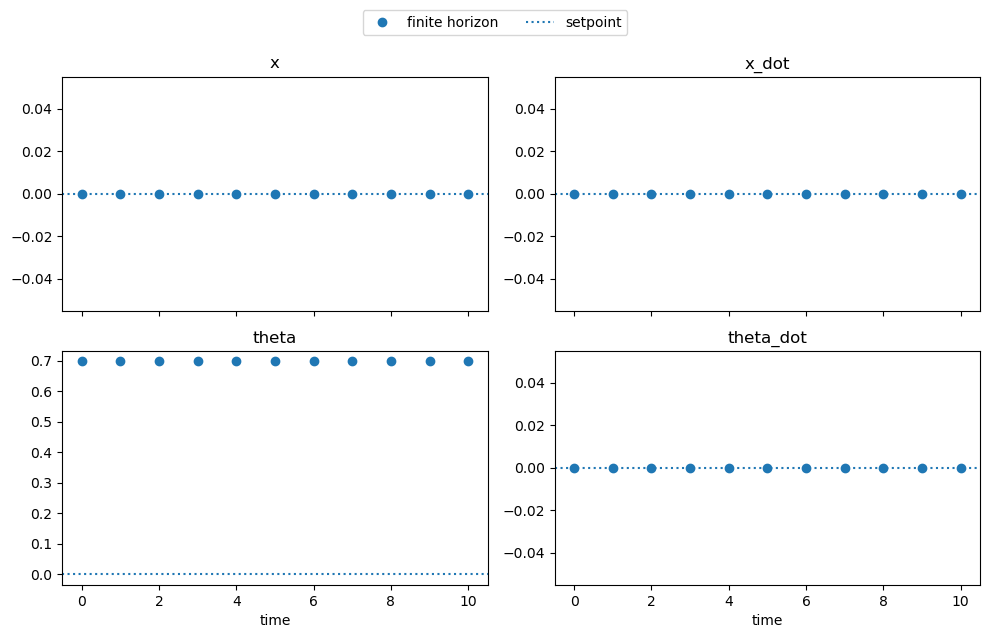

In [2]:
plot_states(m);
plt.show()

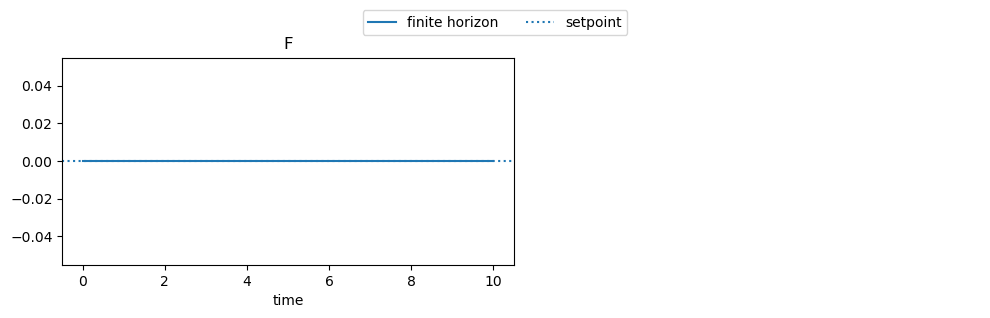

In [3]:
plot_controls(m);
plt.show()

## The cold start

One call, no equilibrium solve: the targets come from the declared
pairings and the start from the declared initial condition.

In [4]:
print(drto.cold_start_dynamic(m))

drto cold_start_dynamic (interpolate to the targets)
  states        : 4 on a line across 31 grid points
  derivatives   : 124 at the line's slope
  controls      : 1 at their targets
  segment       : (none attached)
  point solves  : run (pyomo-pounce block solve)
  pyomo-pounce initialize (fill -> repair -> block-solve)
    decisions held: 155
    values filled : 0
    projection    : skipped
    pyomo-pounce block_initialize
      decisions fixed   : 0
      system square     : True
      blocks solved     : 131 (131 by Newton 1x1, 0 subsystem solves)
      vars initialized  : 131
      left untouched    : 0 underdetermined, 0 overdetermined


## After

Each state runs on its line from its initial condition to its upright
target, and the control holds its target; a state whose initial
condition sits on its target keeps a flat line. This is the guess the
first solve starts from: everything consistent except the declared
dynamics, which carry the transient the optimizer has to resolve.

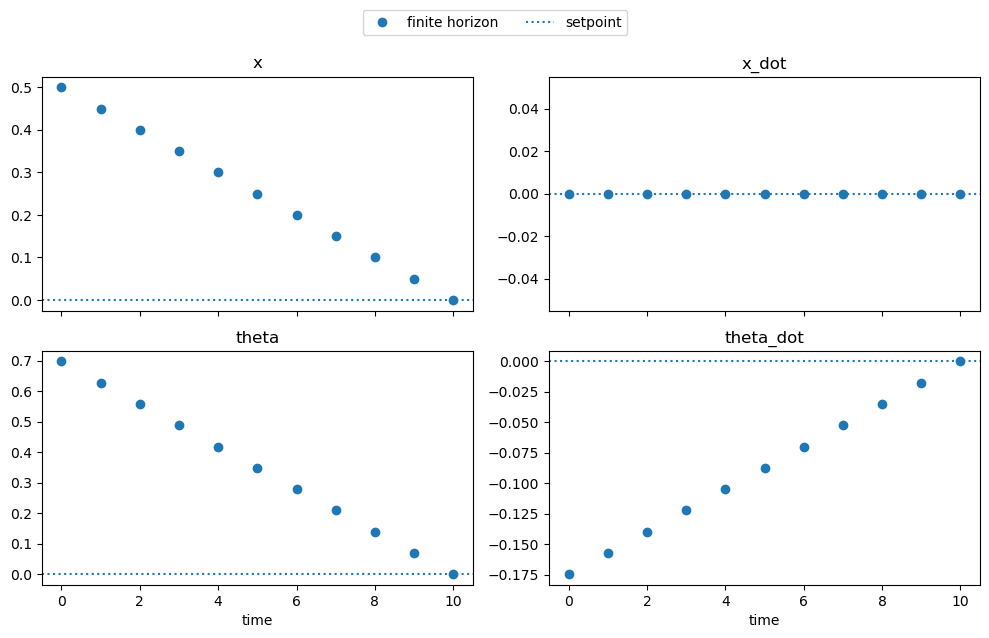

In [5]:
plot_states(m);
plt.show()

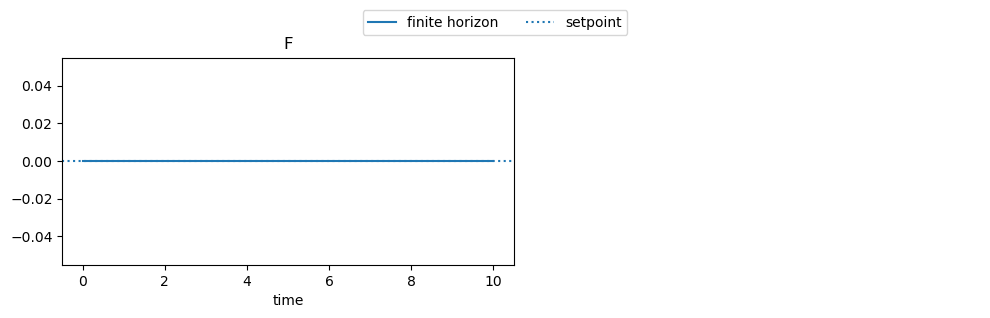

In [6]:
plot_controls(m);
plt.show()

## The first solve

The infinite-horizon controller from the cold-started guess.

In [7]:
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
res = pyo.SolverFactory("pounce").solve(m, tee=False)
print(res.solver.termination_condition)

optimal


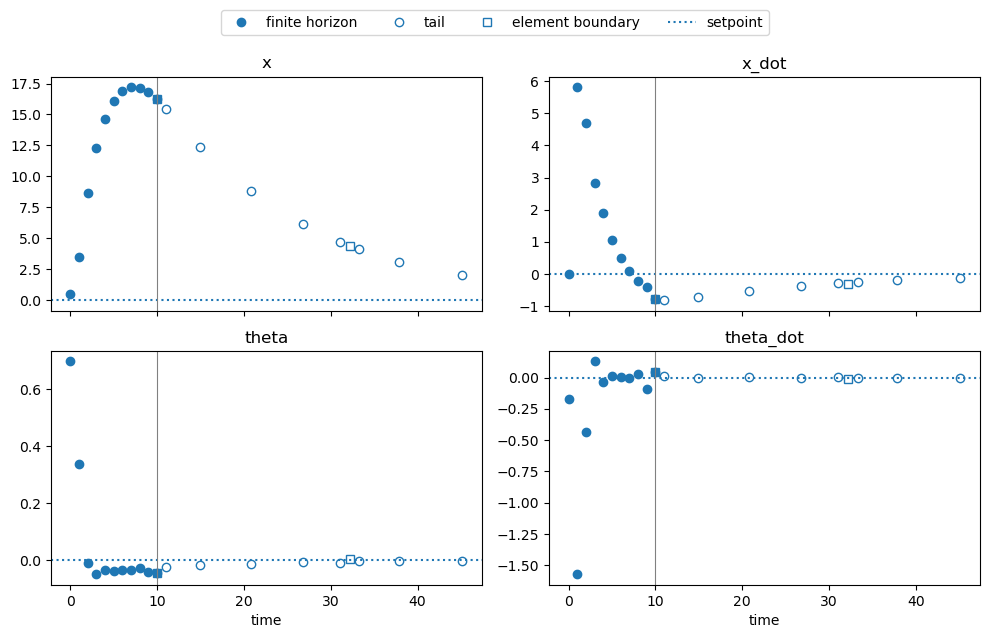

In [8]:
plot_states(m);
plt.show()

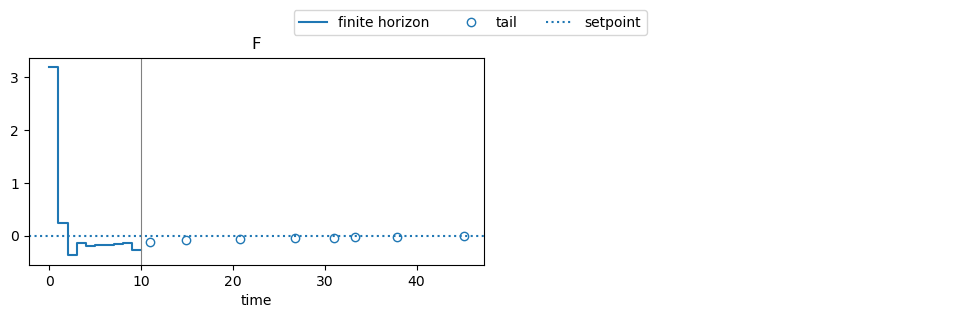

In [9]:
plot_controls(m);
plt.show()